## Exploratory Data Analysis and Feature Engineering

## Before Integration

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

print("All libraries imported successfully")

All libraries imported successfully


### Data Import and Overview

The first part of the EDA is confirming data columns and information. Next is a simple data cleaning, merging the sets and finally a thorough cleaning process, and some exploratory analysis of the dataset. 

In [2]:
df1 = pd.read_csv("../data/raw/NP_dataset.csv")
df2 = pd.read_csv("../data/raw/NP_dataset_small_molecules.csv")
df3 = pd.read_csv("../data/raw/NP_dataset_formulations.csv")
df4 = pd.read_excel("../data/raw/mp_dataset_initial.xlsx")
print("All datasets loaded successfully")

All datasets loaded successfully


In [3]:
print(f"Df1 shape: {df1.shape}")  
df1.head()

Df1 shape: (433, 18)


,polymer_MW,LA/GA,mol_MW,mol_logP,mol_TPSA,mol_melting_point,mol_Hacceptors,mol_Hdonors,mol_heteroatoms,drug/polymer,surfactant_concentration,surfactant_HLB,aqueous/organic,pH,solvent_polarity_index,particle_size,EE,LC
0,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,1.00,1.5,18.0,4.0,0,5.1,210.0,25.18,20.12
1,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.50,1.5,18.0,4.0,0,5.1,198.0,44.83,18.31
2,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.20,1.5,18.0,4.0,0,5.1,190.0,51.83,9.39
3,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.10,1.5,18.0,4.0,0,5.1,181.0,86.60,7.97
4,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.05,1.5,18.0,4.0,0,5.1,232.0,60.60,2.94


In [4]:
print(f"Df2 shape: {df2.shape}") 
df2.head()

Df2 shape: (65, 3)


,small_molecule_name,canonical_SMILES,mol_melting_point
0,sparfloxacin,O=C(O)C1=CN(C2=C(F)C(=C(F)C(N)=C2C1=O)N3CC(NC(...,267.5
1,diazepam,O=C1N(C=2C=CC(Cl)=CC2C(=NC1)C=3C=CC=CC3)C,132.0
2,rivastigmine-tartrate,O=C(O)C(O)C(O)C(=O)O.O=C(OC1=CC=CC(=C1)C(N(C)C...,123.5
3,flurbiprofen,O=C(O)C(C=1C=CC(=C(F)C1)C=2C=CC=CC2)C,110.1
4,docetaxel,O=C(OC(C)(C)C)NC(C=1C=CC=CC1)C(O)C(=O)OC2C(=C3...,232.0


In [5]:
print(f"Df3 shape: {df3.shape}") 
df3.head()     

Df3 shape: (433, 13)


,reference,small_molecule_name,surfactant_name,solvent,polymer_MW,LA/GA,drug/polymer,surfactant_concentration,aqueous/organic,pH,particle_size,EE,LC
0,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone,14.0,1.0,1.00,1.5,4.0,0,210.0,25.18,20.12
1,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone,14.0,1.0,0.50,1.5,4.0,0,198.0,44.83,18.31
2,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone,14.0,1.0,0.20,1.5,4.0,0,190.0,51.83,9.39
3,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone,14.0,1.0,0.10,1.5,4.0,0,181.0,86.60,7.97
4,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone,14.0,1.0,0.05,1.5,4.0,0,232.0,60.60,2.94


In [6]:
print(f"Df4 shape: {df4.shape}")
df4.head()


Df4 shape: (4913, 17)


,Formulation Index,Drug,Drug SMILES,Polymer Mw,Polymer Mn,Polymer Molecular Weight (unit not specified),PDI,LA/GA,Formulation Method,Initial Drug-to-Polymer Ratio,Particle Size,Drug Loading Capacity,Drug Encapsulation Efficiency,Solubility Enhancer Concentration,Time,Release,DOI
0,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,0.000000,0.000000,10.3390/ijms241914729
1,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,1.889764,0.062622,10.3390/ijms241914729
2,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,7.181102,0.056751,10.3390/ijms241914729
3,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,13.984252,0.058708,10.3390/ijms241914729
4,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,27.968504,0.058708,10.3390/ijms241914729


Checking for column and data types so we know what matches, what columns have the same content but different names and what columns to drop. 

In [7]:
for i, df in enumerate([df1, df2, df3, df4], 1):
    print(f"\nDataset {i}")
    print(df.dtypes)


Dataset 1
polymer_MW                  float64
LA/GA                       float64
mol_MW                      float64
mol_logP                    float64
mol_TPSA                    float64
mol_melting_point           float64
mol_Hacceptors                int64
mol_Hdonors                   int64
mol_heteroatoms               int64
drug/polymer                float64
surfactant_concentration    float64
surfactant_HLB              float64
aqueous/organic             float64
pH                            int64
solvent_polarity_index      float64
particle_size               float64
EE                          float64
LC                          float64
dtype: object

Dataset 2
small_molecule_name        str
canonical_SMILES           str
mol_melting_point      float64
dtype: object

Dataset 3
reference                       str
small_molecule_name             str
surfactant_name                 str
solvent                         str
polymer_MW                  float64
LA/GA             

### Notes on Integration Strategy
From the columns, it is noticeable that some columns have the same data but different names. The next step is to standardize the column names. 
a
The columns that match include: 
- particle size, pH, surfactant concentration, small molecule name, LA/GA, polymer MW aqueous/organic.

Columns with the same content but different names include: 

- Drug-to-polymer ratio, drug encapsulation efficiency, loading capacity, Smiles, PDI, surfactant concentration, molecule name. 

Dataset 4 requires the most adjustment based on this analysis. The other tables have similar names, with a slight difference.

Before we start working on the data, I will copy the tables to the processed folder so that the raw data can stay intact for reference and in case any irreversible issues arise later on.


In [8]:
datasets = {
    "dataset1.csv": df1,
    "dataset2.csv": df2,
    "dataset3.csv": df3,
    "dataset4.csv": df4 } 

for filename, dataframe in datasets.items():
    path = os.path.join("../data/processed/", filename)
    dataframe.to_csv(path, index=False)
print("All datasets saved in processed folder")

All datasets saved in processed folder


In [9]:
#using the processed datasets going forward
df1 = pd.read_csv("../data/processed/dataset1.csv")
df2 = pd.read_csv("../data/processed/dataset2.csv")
df3 = pd.read_csv("../data/processed/dataset3.csv")
df4 = pd.read_csv("../data/processed/dataset4.csv")


In [10]:
df4 = df4.rename(columns={"Particle Size": "particle_size", "Polymer MW": "polymer_MW", "Solubility Enhancer Concentration": "surfactant_concentration", "Drug Loading Capacity": "LC",
    "Drug Encapsulation Efficiency": "EE","Drug":"small_molecule_name", "Initial Drug-to-Polymer Ratio": "drug/polymer", "Drug SMILES": "canonical_SMILES", "Encapsulation Efficiency (%)": "encapsulation_efficiency_percent"})
df4.head()

,Formulation Index,small_molecule_name,canonical_SMILES,Polymer Mw,Polymer Mn,Polymer Molecular Weight (unit not specified),PDI,LA/GA,Formulation Method,drug/polymer,particle_size,LC,EE,surfactant_concentration,Time,Release,DOI
0,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,0.000000,0.000000,10.3390/ijms241914729
1,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,1.889764,0.062622,10.3390/ijms241914729
2,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,7.181102,0.056751,10.3390/ijms241914729
3,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,13.984252,0.058708,10.3390/ijms241914729
4,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,27.968504,0.058708,10.3390/ijms241914729


Before merging, we have to ensure all text columns that overlap are in lower case.

In [11]:
df2["small_molecule_name"] = df2["small_molecule_name"].str.strip().str.lower()
df3["small_molecule_name"] = df3["small_molecule_name"].str.strip().str.lower()
df4["small_molecule_name"] = df4["small_molecule_name"].str.strip().str.lower()
print("Small molecule names standardized in both datasets")

Small molecule names standardized in both datasets


Confirm all tables and look for any missed similarities. 

In [12]:
# Pairwise common columns (this is the most important part)
print("\nPairwise Common Columns\n")

pairs = [(df1, df2, 'df1', 'df2'),
         (df1, df3, 'df1', 'df3'),
         (df1, df4, 'df1', 'df4'),
         (df2, df3, 'df2', 'df3'),
         (df2, df4, 'df2', 'df4'),
         (df3, df4, 'df3', 'df4')]

for dfa, dfb, name_a, name_b in pairs:
    common = sorted(set(dfa.columns) & set(dfb.columns))
    print(f"Common columns between {name_a} and {name_b}:")
    print(common if common else "None")
    print(f"   → Count: {len(common)}\n")

# Columns that appear in ALL 4 dataframes (usually very few or empty)
common_all = set(df1.columns) & set(df2.columns) & set(df3.columns) & set(df4.columns)
print(" Columns present in ALL 4 dataframes")
print(sorted(common_all) if common_all else "None (this is normal)")



Pairwise Common Columns

Common columns between df1 and df2:
['mol_melting_point']
   → Count: 1

Common columns between df1 and df3:
['EE', 'LA/GA', 'LC', 'aqueous/organic', 'drug/polymer', 'pH', 'particle_size', 'polymer_MW', 'surfactant_concentration']
   → Count: 9

Common columns between df1 and df4:
['EE', 'LA/GA', 'LC', 'drug/polymer', 'particle_size', 'surfactant_concentration']
   → Count: 6

Common columns between df2 and df3:
['small_molecule_name']
   → Count: 1

Common columns between df2 and df4:
['canonical_SMILES', 'small_molecule_name']
   → Count: 2

Common columns between df3 and df4:
['EE', 'LA/GA', 'LC', 'drug/polymer', 'particle_size', 'small_molecule_name', 'surfactant_concentration']
   → Count: 7

 Columns present in ALL 4 dataframes
None (this is normal)


In [13]:
# Checking mean, std, of each target from the esixting data. This will be used later on to check quality of ML model
TARGETS = ['EE', 'particle_size', 'LC']  

datasets = {
    1: df1,
    3: df3,
}

for i, df in datasets.items():
    print(f"\nDataset {i} target statistics:")
    for t in TARGETS:
        print(f"  {t}: mean={df[t].mean():.2f}, std={df[t].std():.2f}, min={df[t].min():.2f}, max={df[t].max():.2f}")


Dataset 1 target statistics:
  EE: mean=64.65, std=23.60, min=0.00, max=98.90
  particle_size: mean=189.15, std=101.16, min=20.20, max=1012.04
  LC: mean=8.80, std=7.15, min=0.00, max=36.51

Dataset 3 target statistics:
  EE: mean=64.65, std=23.60, min=0.00, max=98.90
  particle_size: mean=189.15, std=101.16, min=20.20, max=1012.04
  LC: mean=8.80, std=7.15, min=0.00, max=36.51


#### df1 and df3 Notes

From the little analysis, we can tell that datasets 1 and 3 are almost certainly the same experiment. Dataset 1 has additional drug 
molecular properties, and dataset 3 has drug names and experimental details. 

In [14]:
# Column overlap between D1 and D3
common_cols = set(df1.columns) & set(df3.columns)
print(f"\nCommon columns: {common_cols}")

# Check exact column names (case, underscores matter)
print(f"\nD1 columns: {df1.columns.tolist()}")
print(f"D3 columns: {df3.columns.tolist()}")

print(f"Df1 shape: {df1.shape}")  
print(f"Df3 shape: {df3.shape}")  


Common columns: {'LA/GA', 'drug/polymer', 'particle_size', 'EE', 'LC', 'pH', 'aqueous/organic', 'surfactant_concentration', 'polymer_MW'}

D1 columns: ['polymer_MW', 'LA/GA', 'mol_MW', 'mol_logP', 'mol_TPSA', 'mol_melting_point', 'mol_Hacceptors', 'mol_Hdonors', 'mol_heteroatoms', 'drug/polymer', 'surfactant_concentration', 'surfactant_HLB', 'aqueous/organic', 'pH', 'solvent_polarity_index', 'particle_size', 'EE', 'LC']
D3 columns: ['reference', 'small_molecule_name', 'surfactant_name', 'solvent', 'polymer_MW', 'LA/GA', 'drug/polymer', 'surfactant_concentration', 'aqueous/organic', 'pH', 'particle_size', 'EE', 'LC']
Df1 shape: (433, 18)
Df3 shape: (433, 13)


In [15]:
# Checking if rows align exactly on shared numeric columns
shared_cols = ['aqueous/organic', 'pH', 'drug/polymer', 'surfactant_concentration', 'particle_size', 'LA/GA', 'LC', 'polymer_MW', 'EE']

# Test first few rows
for col in shared_cols:
    if col in df1.columns and col in df3.columns:
        # Check if values match (allowing small float tolerance)
        matches = np.isclose(df1[col].values, df3[col].values, rtol=1e-5, atol=1e-8)
        print(f"{col}: {matches.sum()}/{len(matches)} matches ({matches.sum()/len(matches)*100:.1f}%)")
        
        if matches.sum() < len(matches):
            print(f"  → Mismatch at indices: {np.where(~matches)[0][:5]}")

# If mismatches exist, sort both by a compound key first
any_mismatch = False
if any_mismatch:
    sort_keys = ['polymer_MW', 'LA/GA', 'drug/polymer']
    df1_sorted = df1.sort_values(by=sort_keys).reset_index(drop=True)
    df3_sorted = df3.sort_values(by=sort_keys).reset_index(drop=True)
else:
    df1_sorted = df1.reset_index(drop=True)
    df3_sorted = df3.reset_index(drop=True)

aqueous/organic: 433/433 matches (100.0%)
pH: 433/433 matches (100.0%)
drug/polymer: 433/433 matches (100.0%)
surfactant_concentration: 433/433 matches (100.0%)
particle_size: 433/433 matches (100.0%)
LA/GA: 433/433 matches (100.0%)
LC: 433/433 matches (100.0%)
polymer_MW: 433/433 matches (100.0%)
EE: 433/433 matches (100.0%)


We have now confirmed that the content in dataset 1 and dataset 3 are the same (they were derived from the same research). Merging them is the next step. This process will be done in the data_loader.py folder. Further analysis of the data is needed to understand how to handle datasets 2 and 4.

#### df4 and df2 notes

Datasets 2 and 4 offer more value in SMILES, which are highly useful in the model. df2 is a small, clear dataset, and thus would be better as the primary source for adding smiles to the main table df13. Df4 is used as a secondary option in case there are drug names in the main dataset that aren't in df2. Df4 offers great information on drug kinetics, which would help create an even better quality model, but would increase complexity at this stage. This model is created as a static model, time and release kinetics are not included. 

In [16]:
df4.head()

,Formulation Index,small_molecule_name,canonical_SMILES,Polymer Mw,Polymer Mn,Polymer Molecular Weight (unit not specified),PDI,LA/GA,Formulation Method,drug/polymer,particle_size,LC,EE,surfactant_concentration,Time,Release,DOI
0,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,0.000000,0.000000,10.3390/ijms241914729
1,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,1.889764,0.062622,10.3390/ijms241914729
2,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,7.181102,0.056751,10.3390/ijms241914729
3,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,13.984252,0.058708,10.3390/ijms241914729
4,1,moxidectin,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,75.0,NaN,NaN,NaN,3.0,O/W,0.666667,47.723,35.41,88.3,0.5,27.968504,0.058708,10.3390/ijms241914729


In [17]:
df2.head()  

,small_molecule_name,canonical_SMILES,mol_melting_point
0,sparfloxacin,O=C(O)C1=CN(C2=C(F)C(=C(F)C(N)=C2C1=O)N3CC(NC(...,267.5
1,diazepam,O=C1N(C=2C=CC(Cl)=CC2C(=NC1)C=3C=CC=CC3)C,132.0
2,rivastigmine-tartrate,O=C(O)C(O)C(O)C(=O)O.O=C(OC1=CC=CC(=C1)C(N(C)C...,123.5
3,flurbiprofen,O=C(O)C(C=1C=CC(=C(F)C1)C=2C=CC=CC2)C,110.1
4,docetaxel,O=C(OC(C)(C)C)NC(C=1C=CC=CC1)C(O)C(=O)OC2C(=C3...,232.0


 ## After Integration

### Further Exploratory Data Analysis

This section provides an overview of the merged dataset, including drug distribution, data completeness, and key summary statistics.

In [18]:
df13 = pd.read_csv("../data/processed/df13.csv")
df13.head()

,polymer_MW,LA/GA,mol_MW,mol_logP,mol_TPSA,mol_melting_point,mol_Hacceptors,mol_Hdonors,mol_heteroatoms,drug/polymer,...,aqueous/organic,pH,solvent_polarity_index,particle_size,EE,LC,reference,small_molecule_name,surfactant_name,solvent
0,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,1.00,...,4.0,0,5.1,210.0,25.18,20.12,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone
1,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.50,...,4.0,0,5.1,198.0,44.83,18.31,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone
2,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.20,...,4.0,0,5.1,190.0,51.83,9.39,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone
3,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.10,...,4.0,0,5.1,181.0,86.60,7.97,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone
4,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.05,...,4.0,0,5.1,232.0,60.60,2.94,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone


/var/folders/cs/xrtnc08x2x38q56mjr45br240000gn/T/ipykernel_15252/1757574249.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


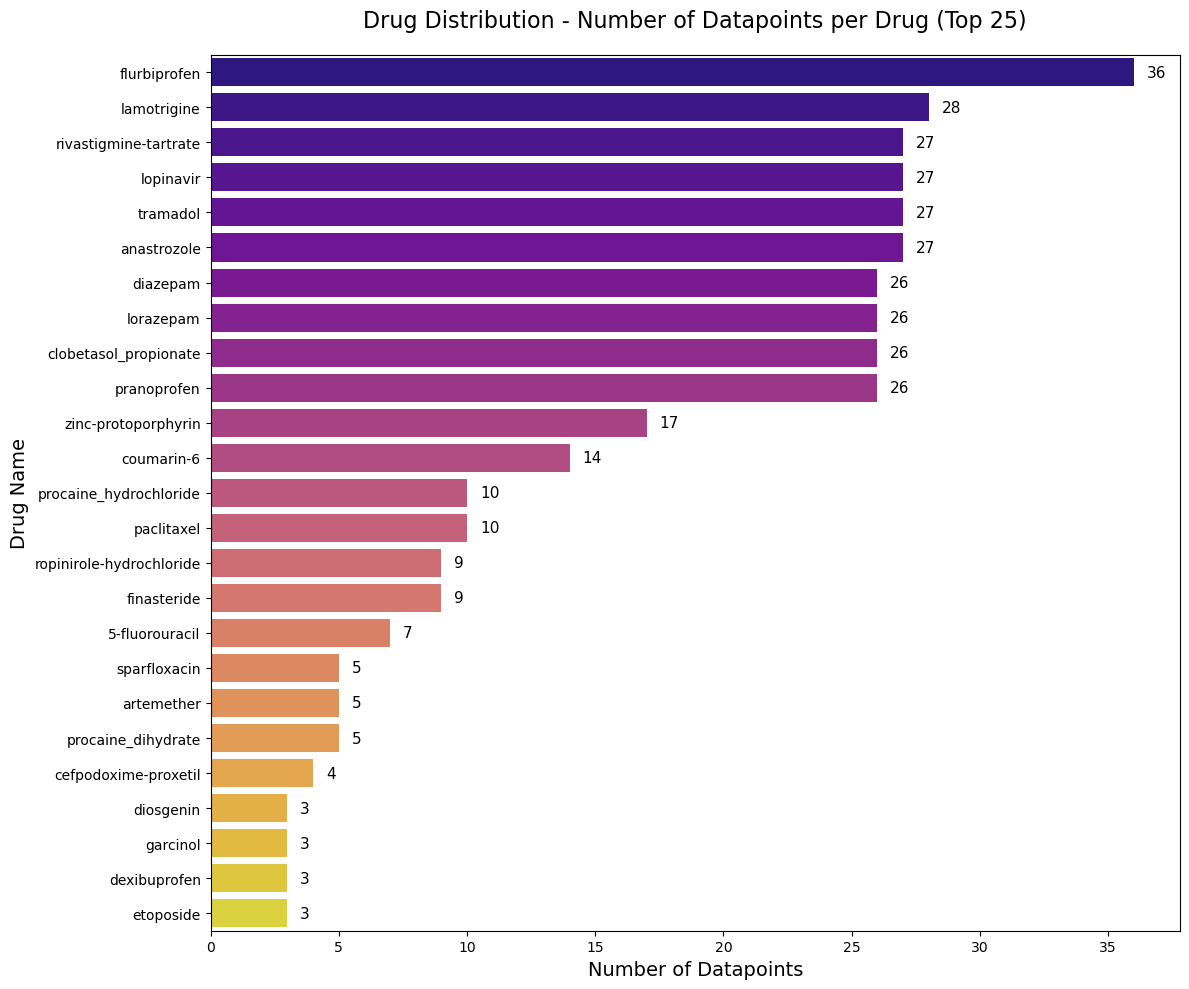

In [34]:
# Calculate drug counts
drug_counts = df13['small_molecule_name'].value_counts().reset_index()
drug_counts.columns = ['Drug', 'Number of Datapoints']

# Sort by count (highest first)
drug_counts = drug_counts.sort_values(by='Number of Datapoints', ascending=False)

plt.figure(figsize=(12, 10))

sns.barplot(
    data=drug_counts.head(25),           # Show top 25 drugs 
    y='Drug', 
    x='Number of Datapoints',
    palette='plasma'
)

plt.title('Drug Distribution - Number of Datapoints per Drug (Top 25)', fontsize=16, pad=20)
plt.xlabel('Number of Datapoints', fontsize=14)
plt.ylabel('Drug Name', fontsize=14)

# Add value labels on the bars
for i, v in enumerate(drug_counts.head(25)['Number of Datapoints']):
    plt.text(v + 0.5, i, str(v), va='center', fontsize=11)

plt.tight_layout()
plt.show()

**Notes / Observations**

The dataset is heavily dominated by a few drugs, with flurbiprofen having the highest number of records (36), followed by several drugs with 26–28 datapoints (lamotrigine, rivastigmine-tartrate, lopinavir, tramadol, anastrozole).

This imbalance suggests that the model may perform better on frequently occurring drugs and may require techniques such as grouping rare drugs or using molecular descriptors to improve generalization.

In [21]:
# Count frequency of each drug
drug_freq = df13['small_molecule_name'].value_counts().reset_index()
drug_freq.columns = ['Drug', 'Number_of_Datapoints']

# Drugs that appear only once
single_drugs = drug_freq[drug_freq['Number_of_Datapoints'] == 1]

print(f"Total unique drugs in dataset: {len(drug_freq)}")
print(f"Number of drugs that appear only once: {len(single_drugs)}")
print(f"Percentage of singleton drugs: {len(single_drugs)/len(drug_freq)*100:.1f}%")


Total unique drugs in dataset: 65
Number of drugs that appear only once: 33
Percentage of singleton drugs: 50.8%


**Notes / Observations**

A significant portion of the dataset consists of drugs that appear only once (33 drugs, representing 50% of all unique drugs). This highlights the long-tailed nature of the data, where a few drugs (such as flurbiprofen, lamotrigine, and rivastigmine-tartrate) dominate the records, while many others have limited representation. This imbalance can be considered by incorporating molecular descriptors (SMILES) to enhance model generalization for both common and rare drugs.

In [22]:
df13.head() 

,polymer_MW,LA/GA,mol_MW,mol_logP,mol_TPSA,mol_melting_point,mol_Hacceptors,mol_Hdonors,mol_heteroatoms,drug/polymer,...,aqueous/organic,pH,solvent_polarity_index,particle_size,EE,LC,reference,small_molecule_name,surfactant_name,solvent
0,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,1.00,...,4.0,0,5.1,210.0,25.18,20.12,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone
1,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.50,...,4.0,0,5.1,198.0,44.83,18.31,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone
2,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.20,...,4.0,0,5.1,190.0,51.83,9.39,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone
3,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.10,...,4.0,0,5.1,181.0,86.60,7.97,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone
4,14.0,1.0,392.41,2.08,100.59,267.5,6,3,9,0.05,...,4.0,0,5.1,232.0,60.60,2.94,10.1016/j.nano.2009.10.004,sparfloxacin,PVA,acetone


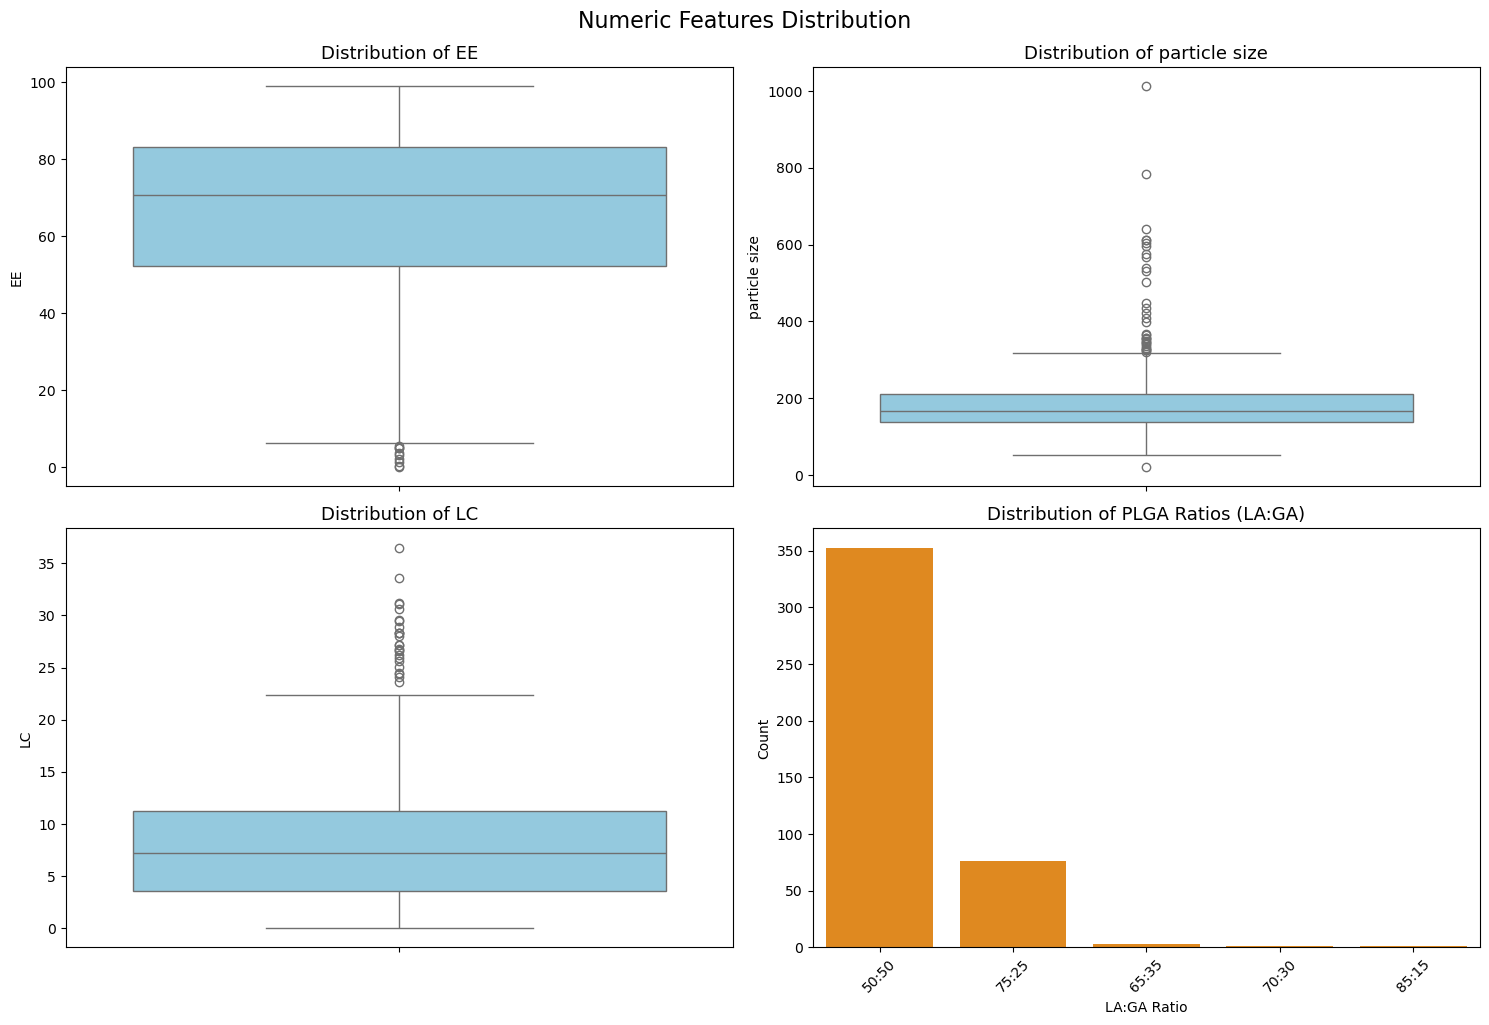

In [27]:
numeric_cols = ['EE', 'particle_size', 'LC']

# Create readable ratio labels
def format_ratio(x):
    if pd.isnull(x):
        return "Unknown"
    la = (x / (1 + x)) * 100
    ga = (1 / (1 + x)) * 100
    return f"{int(round(la))}:{int(round(ga))}"

df13['LA_GA_ratio_label'] = df13['LA/GA'].apply(format_ratio)

plt.figure(figsize=(15, 10))

# Boxplots for EE, Particle Size, and LC
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df13[col], color='skyblue')
    plt.title(f'Distribution of {col.replace("_", " ")}', fontsize=13)
    plt.ylabel(col.replace("_", " "))

# Countplot for LA/GA ratio
plt.subplot(2, 2, 4)
sns.countplot(
    data=df13,
    x='LA_GA_ratio_label',
    order=df13['LA_GA_ratio_label'].value_counts().index,
    color='darkorange'
)

plt.title('Distribution of PLGA Ratios (LA:GA)', fontsize=13)
plt.xlabel('LA:GA Ratio')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle('Numeric Features Distribution', fontsize=16, y=1.02)
plt.show()

In [26]:
df13['LA/GA'].describe()

count    433.000000
mean       1.370855
std        0.790928
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        5.670000
Name: LA/GA, dtype: float64

The figure above presents the distributions of the four main numeric variables in the dataset.

- Encapsulation Efficiency (EE) shows a relatively wide but reasonable spread, with a median around 70% and several low outliers near 0%.

- Particle Size exhibits high variability and a pronounced right skew, with many formulations falling in the 100–300 nm range suitable for EPR effect, but also several large outliers exceeding 600 nm.

- Drug Loading Capacity (LC) has a more compact distribution, with most values concentrated between 5% and 12%.

- LA_ratio_float (lactide proportion) is heavily concentrated at common ratios, particularly 0.5 (50:50 PLGA) and 1.0 (pure PLA), as highlighted by the vertical reference lines.

Overall, the plots show significant heterogeneity in the dataset, especially in particle size and encapsulation efficiency. This variability provides a rich feature space for the ml modeling.


In [24]:
summary_stats = df13[numeric_cols].describe().round(3).T
summary_stats = summary_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]

print("Numeric Features Summary Statistics")
display(summary_stats.style.set_caption("Descriptive Statistics").format("{:.3f}"))

Numeric Features Summary Statistics


,count,mean,std,min,25%,50%,75%,max
EE,433.000,64.651,23.597,0.000,52.300,70.620,83.240,98.900
particle_size,433.000,189.146,101.158,20.200,137.700,167.000,210.300,1012.040
LC,433.000,8.800,7.154,0.000,3.620,7.270,11.220,36.510


**Key Observations:**

- Encapsulation efficiency shows a mean of 64.65% and several low outliers.

- Particle size exhibits high variability, with some formulations exceeding 1000 nm.

- LA_ratio_float is heavily concentrated around common ratios 50:50 and higher-lactide PLGA compositions in the literature.

These distributions highlight the heterogeneity of the dataset and the need for careful preprocessing and modeling strategies in future sections.

,Count,Mean_EE,Mean_Size
small_molecule_name,,,
dexibuprofen,3,88.670000,179.870000
finasteride,9,88.490000,455.570000
diazepam,26,84.310000,206.270000
lorazepam,26,81.550000,210.790000
artemether,5,80.860000,195.220000
flurbiprofen,36,80.470000,211.490000
clobetasol_propionate,26,79.880000,155.850000
paclitaxel,10,79.500000,197.850000
rivastigmine-tartrate,27,72.180000,122.490000


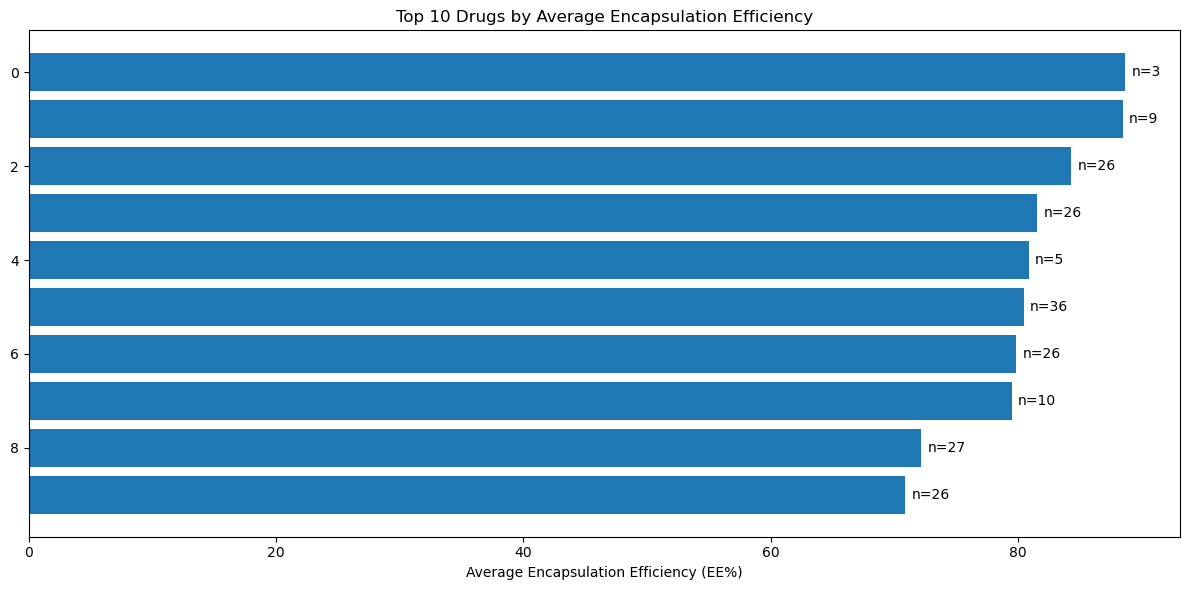

In [32]:
# Top 10 drugs by mean EE% (only drugs with at least 3 records)
drug_ee = df13.groupby('small_molecule_name').agg(
    Count=('small_molecule_name', 'size'),
    Mean_EE=('EE', 'mean'),
    Mean_Size=('particle_size', 'mean')
).round(2)

drug_ee = drug_ee[drug_ee['Count'] >= 3].sort_values(by='Mean_EE', ascending=False).head(10)

display(drug_ee.style.set_caption("Top 10 Drugs by Average Encapsulation Efficiency (EE%)"))

top10_df = drug_ee.reset_index()

plt.figure(figsize=(12, 6))

# Barplot for Mean EE
bars = plt.barh(top10_df.index, top10_df['Mean_EE'])

plt.xlabel('Average Encapsulation Efficiency (EE%)')
plt.title('Top 10 Drugs by Average Encapsulation Efficiency')

# Add count annotations
for i, (ee, count) in enumerate(zip(top10_df['Mean_EE'], top10_df['Count'])):
    plt.text(ee + 0.5, i, f'n={count}', va='center')

plt.gca().invert_yaxis()  # Highest at top
plt.tight_layout()
plt.show()

**Key Observations**
Drugs like dexibuprofen and finasteride show the highest EE% (>88%), indicating strong drug loading performance. However, sample size varies across drugs, so results with larger counts (e.g., flurbiprofen, diazepam) are more reliable.

Differences in particle size across drugs suggest a potential tradeoff between encapsulation efficiency and formulation characteristics. Overall, both drug properties and formulation conditions likely influence EE%. 

**Conclusion**

Looking at the dataset as a whole, a few drugs, especially flurbiprofen, lamotrigine, and rivastigmine-tartrate—make up most of the records, while half of all unique drugs appear only once. This kind of imbalance is common in real-world data, but it does mean that a model trained on this dataset might struggle with rarer drugs. Using SMILES could help the model generalize better across both common and less common drugs.

The data also show a lot of natural variability. Encapsulation efficiency tends to cluster around 65% on average, but there are several very low values near 0%. Particle size varies even more, with most formulations falling into the 100–300 nm range, though some go well beyond 600 nm and even past 1000 nm. Drug loading is fairly consistent, mostly sitting between 5% and 12%. Unsurprisingly, the lactide ratio is heavily concentrated at the two most common values: 0.5 (50:50 PLGA) and 1.0 (pure PLA).

When we look at performance by drug, dexibuprofen and finasteride stand out with average encapsulation efficiencies above 88%. Still, these results come from smaller sample sizes, so the numbers for more frequently studied drugs like flurbiprofen and diazepam are more reliable. There also seems to be a trade-off between encapsulation efficiency and particle size depending on the drug, though formulation conditions clearly play a role too.

All in all, this is a rich but expectedly uneven dataset. Moving forward, there needs a system to make use of drug structure information, and account for the wide variability in particle size and encapsulation efficiency during preprocessing and model selection.